# Konačno poređenje modela na skupu za testiranje

Predikcija srčane slabosti primenom metoda mašinskog učenja.

Ovo je poslednja sveska. Uzimamo sve modele iz prethodnih svezaka, u varijanti sa regularizacijom i bez nje, i poredimo ih na skupu za testiranje.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import svm
from sklearn import neighbors
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics

In [28]:
import xgboost

In [30]:
np.random.seed(7)

In [31]:
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

# Učitavanje i pretprocesiranje skupa podataka

Podatke pripremamo na isti način kao u prethodnim sveskama.

In [32]:
data = pd.read_csv('../data/heart.csv')

In [33]:
data['Cholesterol_izmeren'] = (data['Cholesterol'] != 0).astype(int)

In [34]:
data['Cholesterol'] = data['Cholesterol'].replace(0, data.loc[data['Cholesterol'] != 0, 'Cholesterol'].median())

In [35]:
data['RestingBP'] = data['RestingBP'].replace(0, data.loc[data['RestingBP'] != 0, 'RestingBP'].median())

In [36]:
data = pd.get_dummies(data, drop_first=True, dtype=int)

In [37]:
x = data.drop(labels=['HeartDisease'], axis=1)
y = data['HeartDisease']

Nazive atributa pamtimo posebno, jer će nam trebati na graficima.

In [38]:
feature_names = list(x.columns)
feature_names

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'Cholesterol_izmeren',
 'Sex_M',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_Y',
 'ST_Slope_Flat',
 'ST_Slope_Up']

Zarad lakše manipulacije podacima, prelazimo na NumPy matrice.

In [39]:
x = np.array(x)
y = np.array(y)

In [40]:
x.shape

(918, 16)

In [41]:
y.shape

(918,)

Podelu vršimo istom vrednošću parametra <code>random_state</code> kao u prethodnim sveskama, pa je skup za testiranje isti. Validacioni skup nam ovde više ne treba, jer su metaparametri već izabrani u drugoj svesci, pa modele učimo na celom skupu za treniranje.

In [42]:
x_train_validation, x_test, y_train_validation, y_test = model_selection.train_test_split(x, y, test_size=0.2, stratify=y, random_state=7)

In [43]:
x_train_validation.shape

(734, 16)

In [44]:
x_test.shape

(184, 16)

Vršimo standardizaciju atributa.

In [45]:
scaler = preprocessing.StandardScaler()

In [46]:
scaler.fit(x_train_validation)

StandardScaler()

In [47]:
x_train_validation = scaler.transform(x_train_validation)
x_test = scaler.transform(x_test)

# Modeli

Prvo ponavljamo modele bez regularizacije, iste kao u drugoj svesci.

In [48]:
modeli_bez_regularizacije = {
    'Logistička regresija': linear_model.LogisticRegression(C=np.inf, max_iter=5000),
    'SVM (RBF)': svm.SVC(kernel='rbf', C=1000000, probability=True, random_state=7),
    'KNN': neighbors.KNeighborsClassifier(n_neighbors=1),
    'Slučajna šuma': ensemble.RandomForestClassifier(n_estimators=300, max_depth=None, max_features=None, random_state=7),
    'AdaBoost': ensemble.AdaBoostClassifier(estimator=tree.DecisionTreeClassifier(max_depth=None, random_state=7), n_estimators=200, random_state=7),
    'XGBoost': xgboost.XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.3, reg_lambda=0)
}

Zatim modele sa regularizacijom, sa metaparametrima koje smo izabrali u drugoj svesci na validacionom skupu i unakrsnom validacijom.

In [49]:
modeli_sa_regularizacijom = {
    'Logistička regresija': linear_model.LogisticRegression(C=1, max_iter=5000),
    'SVM (RBF)': svm.SVC(kernel='rbf', C=1, gamma=0.1, probability=True, random_state=7),
    'KNN': neighbors.KNeighborsClassifier(n_neighbors=3, weights='uniform'),
    'Slučajna šuma': ensemble.RandomForestClassifier(n_estimators=100, max_depth=None, max_features='sqrt', min_samples_leaf=1, random_state=7),
    'AdaBoost': ensemble.AdaBoostClassifier(estimator=tree.DecisionTreeClassifier(max_depth=2, random_state=7), n_estimators=100, learning_rate=0.1, random_state=7),
    'XGBoost': xgboost.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, reg_lambda=20)
}

Skup za testiranje nije korišćen pri izboru metaparametara, nego samo validacioni skup i unakrsna validacija nad skupom za treniranje.

# Predikcije na skupu za testiranje

Svaki model učimo na celom skupu za treniranje, a zatim računamo njegove predikcije na skupu za testiranje. Za svaki model pamtimo tačnost, preciznost, odziv, F1 meru i AUC.

In [50]:
accuracy_bez = []
precision_bez = []
recall_bez = []
f1_bez = []
roc_auc_bez = []

for naziv, model in modeli_bez_regularizacije.items():
    model.fit(x_train_validation, y_train_validation)

    y_test_predicted = model.predict(x_test)
    y_test_probabilities_predicted = model.predict_proba(x_test)

    accuracy_bez.append(metrics.accuracy_score(y_test, y_test_predicted))
    precision_bez.append(metrics.precision_score(y_test, y_test_predicted))
    recall_bez.append(metrics.recall_score(y_test, y_test_predicted))
    f1_bez.append(metrics.f1_score(y_test, y_test_predicted))
    roc_auc_bez.append(metrics.roc_auc_score(y_test, y_test_probabilities_predicted[:, 1]))

In [51]:
rezultati_bez_regularizacije = pd.DataFrame({'tačnost': accuracy_bez, 'preciznost': precision_bez,
                                             'odziv': recall_bez, 'f1': f1_bez, 'auc': roc_auc_bez},
                                            index=modeli_bez_regularizacije.keys())
rezultati_bez_regularizacije

,tačnost,preciznost,odziv,f1,auc
Logistička regresija,0.842391,0.854369,0.862745,0.858537,0.927068
SVM (RBF),0.815217,0.846939,0.813725,0.830000,0.902917
KNN,0.815217,0.833333,0.833333,0.833333,0.813008
Slučajna šuma,0.864130,0.859813,0.901961,0.880383,0.936992
AdaBoost,0.809783,0.819048,0.843137,0.830918,0.805715
XGBoost,0.864130,0.866667,0.892157,0.879227,0.930894


In [52]:
accuracy_sa = []
precision_sa = []
recall_sa = []
f1_sa = []
roc_auc_sa = []

for naziv, model in modeli_sa_regularizacijom.items():
    model.fit(x_train_validation, y_train_validation)

    y_test_predicted = model.predict(x_test)
    y_test_probabilities_predicted = model.predict_proba(x_test)

    accuracy_sa.append(metrics.accuracy_score(y_test, y_test_predicted))
    precision_sa.append(metrics.precision_score(y_test, y_test_predicted))
    recall_sa.append(metrics.recall_score(y_test, y_test_predicted))
    f1_sa.append(metrics.f1_score(y_test, y_test_predicted))
    roc_auc_sa.append(metrics.roc_auc_score(y_test, y_test_probabilities_predicted[:, 1]))

In [53]:
rezultati_sa_regularizacijom = pd.DataFrame({'tačnost': accuracy_sa, 'preciznost': precision_sa,
                                             'odziv': recall_sa, 'f1': f1_sa, 'auc': roc_auc_sa},
                                            index=modeli_sa_regularizacijom.keys())
rezultati_sa_regularizacijom

,tačnost,preciznost,odziv,f1,auc
Logistička regresija,0.842391,0.854369,0.862745,0.858537,0.927905
SVM (RBF),0.869565,0.861111,0.911765,0.885714,0.938546
KNN,0.853261,0.857143,0.882353,0.869565,0.907042
Slučajna šuma,0.858696,0.839286,0.921569,0.878505,0.947752
AdaBoost,0.864130,0.846847,0.921569,0.882629,0.944225
XGBoost,0.864130,0.881188,0.872549,0.876847,0.948470


# Poređenje

In [54]:
poredjenje = pd.DataFrame({'f1 bez': f1_bez, 'f1 sa': f1_sa,
                           'tačnost bez': accuracy_bez, 'tačnost sa': accuracy_sa},
                          index=modeli_bez_regularizacije.keys())
poredjenje

,f1 bez,f1 sa,tačnost bez,tačnost sa
Logistička regresija,0.858537,0.858537,0.842391,0.842391
SVM (RBF),0.830000,0.885714,0.815217,0.869565
KNN,0.833333,0.869565,0.815217,0.853261
Slučajna šuma,0.880383,0.878505,0.864130,0.858696
AdaBoost,0.830918,0.882629,0.809783,0.864130
XGBoost,0.879227,0.876847,0.864130,0.864130


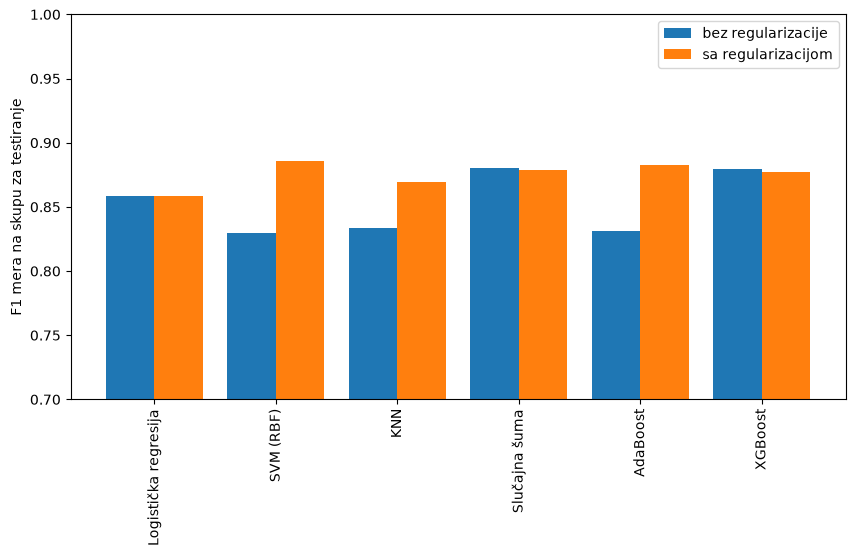

In [55]:
plt.figure(figsize=(10, 5))
plt.bar(np.arange(6) - 0.2, f1_bez, width=0.4, label='bez regularizacije')
plt.bar(np.arange(6) + 0.2, f1_sa, width=0.4, label='sa regularizacijom')
plt.xticks(np.arange(6), list(modeli_bez_regularizacije.keys()), rotation='vertical')
plt.ylabel('F1 mera na skupu za testiranje')
plt.ylim(0.7, 1.0)
plt.legend(loc='best')
plt.show()

Regularizacija najviše pomaže SVM-u, sa 0.830 na 0.886, AdaBoost-u, sa 0.831 na 0.883, i KNN-u, sa 0.833 na 0.870. Kod logističke regresije rezultat je identičan, jer je izabrano <code>C</code> = 1, za koje je model isti kao onaj bez kazne. Kod slučajne šume i XGBoost-a razlika je 0.002 u korist varijante bez regularizacije. To je manje od jedne instance na skupu od 184, dakle u granicama šuma. Unakrsna validacija u drugoj svesci, koja je pouzdanija jer koristi 734 instance, pokazala je da regularizacija i njima pomaže.

# Najbolji i najgori model

Izdvajamo model sa najvećom i model sa najmanjom F1 merom među svim isprobanim varijantama.

In [56]:
svi_modeli = {}

for naziv, model in modeli_bez_regularizacije.items():
    svi_modeli[naziv + ' (bez)'] = model

for naziv, model in modeli_sa_regularizacijom.items():
    svi_modeli[naziv + ' (sa)'] = model

In [57]:
svi_f1 = pd.Series(f1_bez + f1_sa, index=list(svi_modeli.keys()))
svi_f1.sort_values(ascending=False)

SVM (RBF) (sa)                0.885714
AdaBoost (sa)                 0.882629
Slučajna šuma (bez)           0.880383
XGBoost (bez)                 0.879227
Slučajna šuma (sa)            0.878505
XGBoost (sa)                  0.876847
KNN (sa)                      0.869565
Logistička regresija (bez)    0.858537
Logistička regresija (sa)     0.858537
KNN (bez)                     0.833333
AdaBoost (bez)                0.830918
SVM (RBF) (bez)               0.830000
dtype: float64

In [58]:
najbolji_naziv = svi_f1.idxmax()
najgori_naziv = svi_f1.idxmin()

print('Najbolji model:', najbolji_naziv)
print('Najgori model: ', najgori_naziv)

Najbolji model: SVM (RBF) (sa)
Najgori model:  SVM (RBF) (bez)


Klasifikacioni izveštaj najboljeg modela:

In [60]:
najbolji_model = svi_modeli[najbolji_naziv]
y_test_predicted = najbolji_model.predict(x_test)
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        82
           1       0.86      0.91      0.89       102

    accuracy                           0.87       184
   macro avg       0.87      0.86      0.87       184
weighted avg       0.87      0.87      0.87       184



In [61]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[67, 15],
       [ 9, 93]])

Klasifikacioni izveštaj najgoreg modela:

In [62]:
najgori_model = svi_modeli[najgori_naziv]
y_test_predicted_najgori = najgori_model.predict(x_test)
print(metrics.classification_report(y_test, y_test_predicted_najgori))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80        82
           1       0.85      0.81      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.82      0.82      0.82       184



In [63]:
metrics.confusion_matrix(y_test, y_test_predicted_najgori)

array([[67, 15],
       [19, 83]])

Zanimljivo je da su najbolji i najgori model **isti algoritam**, kernelizovani SVM, i da ih razlikuje jedino regularizacija. Sa tvrdom marginom ima F1 meru 0.830, a sa izabranim vrednostima <code>C</code> = 1 i <code>gamma</code> = 0.1 ima 0.886. Matrice konfuzije pokazuju odakle dolazi razlika. Obe varijante jednako rade sa zdravim pacijentima, 67 tačno i 15 pogrešno, ali regularizovani model propušta 9 bolesnih, a neregularizovani 19, dakle više nego dvostruko. U medicinskom kontekstu je baš to najskuplja greška, jer znači da je bolestan pacijent proglašen zdravim.

# ROC krive

Za izračunavanje AUC mere i iscrtavanje ROC krive koriste se funkcije <code>roc_auc_score()</code> i <code>RocCurveDisplay.from_estimator()</code> iz modula <code>metrics</code>. Drugoj funkciji se prosleđuje model, a ne predikcije modela.

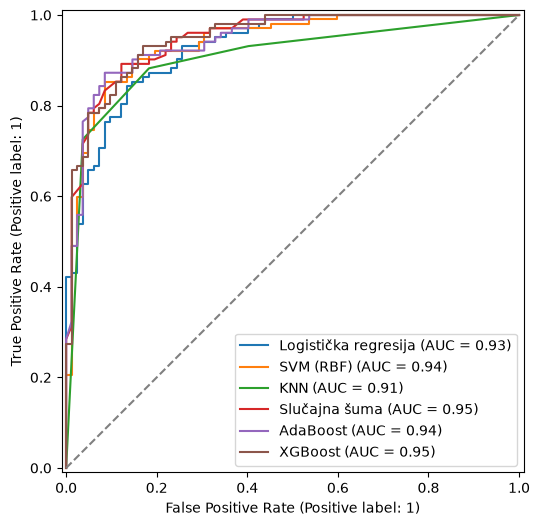

In [64]:
plt.figure(figsize=(7, 6))
ax = plt.gca()

for naziv, model in modeli_sa_regularizacijom.items():
    metrics.RocCurveDisplay.from_estimator(model, x_test, y_test, name=naziv, ax=ax)

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.legend(loc='lower right')
plt.show()

Sve krive su daleko iznad dijagonale, koja odgovara nasumičnom pogađanju. Međusobno su vrlo bliske, pa nijedan model nema izrazitu prednost na svim pragovima odlučivanja.

# Pomeranje praga odlučivanja

Podrazumevani prag od 0.5 nije obavezan. Ako želimo da smanjimo broj lažno negativnih, prag možemo spustiti, pa model češće proglašava pacijenta bolesnim. Cena je manja preciznost i više lažno pozitivnih.

In [65]:
y_test_probabilities_predicted = najbolji_model.predict_proba(x_test)

In [66]:
pragovi = [0.3, 0.4, 0.5, 0.6, 0.7]

precision_pragovi = []
recall_pragovi = []

for prag in pragovi:
    y_test_predicted = (y_test_probabilities_predicted[:, 1] > prag).astype(int)

    precision_pragovi.append(metrics.precision_score(y_test, y_test_predicted))
    recall_pragovi.append(metrics.recall_score(y_test, y_test_predicted))

In [67]:
rezultati_pragovi = pd.DataFrame({'preciznost': precision_pragovi, 'odziv': recall_pragovi},
                                 index=pragovi)
rezultati_pragovi

,preciznost,odziv
0.3,0.798319,0.931373
0.4,0.831858,0.921569
0.5,0.867925,0.901961
0.6,0.880000,0.862745
0.7,0.923913,0.833333


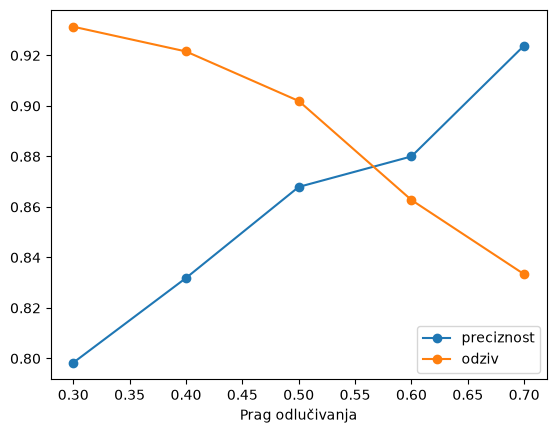

In [68]:
plt.plot(pragovi, precision_pragovi, marker='o', label='preciznost')
plt.plot(pragovi, recall_pragovi, marker='o', label='odziv')
plt.xlabel('Prag odlučivanja')
plt.legend(loc='best')
plt.show()

Sa spuštanjem praga odziv raste, a preciznost opada. Na pragu 0.4 model prepoznaje 92% bolesnih umesto 90%, uz pad preciznosti sa 0.868 na 0.832. Za primenu u kojoj je cilj da se propusti što manje bolesnih pacijenata biramo niži prag.

# Neuronska mreža na skupu za testiranje

Da bi poređenje bilo potpuno, na isti skup za testiranje primenjujemo i mreže iz treće sveske, obe varijante, sa istom arhitekturom od 32 i 16 neurona.

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import regularizers

import tensorflow as tf
tf.random.set_seed(7)

In [70]:
number_of_features = x.shape[1]
output_size = 1

Mreža bez regularizacije:

In [71]:
mreza_bez = Sequential()
mreza_bez.add(Dense(units=32, input_shape=(number_of_features, ), activation='relu'))
mreza_bez.add(Dense(units=16, activation='relu'))
mreza_bez.add(Dense(units=output_size, activation='sigmoid'))

In [73]:
mreza_bez.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [74]:
mreza_bez.fit(x_train_validation, y_train_validation, epochs=100, batch_size=32, verbose=0)

Mreža sa Dropout slojevima i l2 kaznom:

In [75]:
mreza_sa = Sequential()
mreza_sa.add(Dense(units=32, input_shape=(number_of_features, ), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
mreza_sa.add(Dropout(0.3))
mreza_sa.add(Dense(units=16, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
mreza_sa.add(Dropout(0.3))
mreza_sa.add(Dense(units=output_size, activation='sigmoid'))

In [76]:
mreza_sa.compile(loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [77]:
mreza_sa.fit(x_train_validation, y_train_validation, epochs=100, batch_size=32, verbose=0)

Predikcije obe mreže na skupu za testiranje:

In [78]:
y_test_probabilities_mreza_bez = mreza_bez.predict(x_test, verbose=0)
y_test_predicted_mreza_bez = (y_test_probabilities_mreza_bez > 0.5).astype(int)

y_test_probabilities_mreza_sa = mreza_sa.predict(x_test, verbose=0)
y_test_predicted_mreza_sa = (y_test_probabilities_mreza_sa > 0.5).astype(int)

In [79]:
print(metrics.classification_report(y_test, y_test_predicted_mreza_sa))

              precision    recall  f1-score   support

           0       0.88      0.83      0.86        82
           1       0.87      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



# Konačno upoređivanje modela

Sve rezultate skupljamo u jednu tabelu i sortiramo po F1 meri.

In [81]:
zbirna_tabela = pd.concat([rezultati_bez_regularizacije, rezultati_sa_regularizacijom])
zbirna_tabela.index = list(svi_modeli.keys())

zbirna_tabela.loc['Neuronska mreža (bez)'] = [metrics.accuracy_score(y_test, y_test_predicted_mreza_bez),
                                              metrics.precision_score(y_test, y_test_predicted_mreza_bez),
                                              metrics.recall_score(y_test, y_test_predicted_mreza_bez),
                                              metrics.f1_score(y_test, y_test_predicted_mreza_bez),
                                              metrics.roc_auc_score(y_test, y_test_probabilities_mreza_bez[:, 0])]

zbirna_tabela.loc['Neuronska mreža (sa)'] = [metrics.accuracy_score(y_test, y_test_predicted_mreza_sa),
                                             metrics.precision_score(y_test, y_test_predicted_mreza_sa),
                                             metrics.recall_score(y_test, y_test_predicted_mreza_sa),
                                             metrics.f1_score(y_test, y_test_predicted_mreza_sa),
                                             metrics.roc_auc_score(y_test, y_test_probabilities_mreza_sa[:, 0])]

zbirna_tabela.sort_values('f1', ascending=False)

,tačnost,preciznost,odziv,f1,auc
Neuronska mreža (sa),0.875000,0.869159,0.911765,0.889952,0.946198
SVM (RBF) (sa),0.869565,0.861111,0.911765,0.885714,0.938546
AdaBoost (sa),0.864130,0.846847,0.921569,0.882629,0.944225
Slučajna šuma (bez),0.864130,0.859813,0.901961,0.880383,0.936992
XGBoost (bez),0.864130,0.866667,0.892157,0.879227,0.930894
Slučajna šuma (sa),0.858696,0.839286,0.921569,0.878505,0.947752
XGBoost (sa),0.864130,0.881188,0.872549,0.876847,0.948470
Neuronska mreža (bez),0.853261,0.850467,0.892157,0.870813,0.933525
KNN (sa),0.853261,0.857143,0.882353,0.869565,0.907042
Logistička regresija (bez),0.842391,0.854369,0.862745,0.858537,0.927068


Na vrhu tabele su SVM sa regularizacijom, AdaBoost sa regularizacijom i neuronska mreža. Razlike među prvih nekoliko modela su unutar 0.01 F1 mere. Na dnu tabele su tri varijante bez regularizacije, KNN, AdaBoost i SVM. Neuronska mreža pokazuje dobre rezultate, ali klasične modele ne nadmašuje.

# Šta model koristi za odluku

Kod ansambala stabala značajnost atributa čitamo iz atributa <code>feature_importances_</code>:

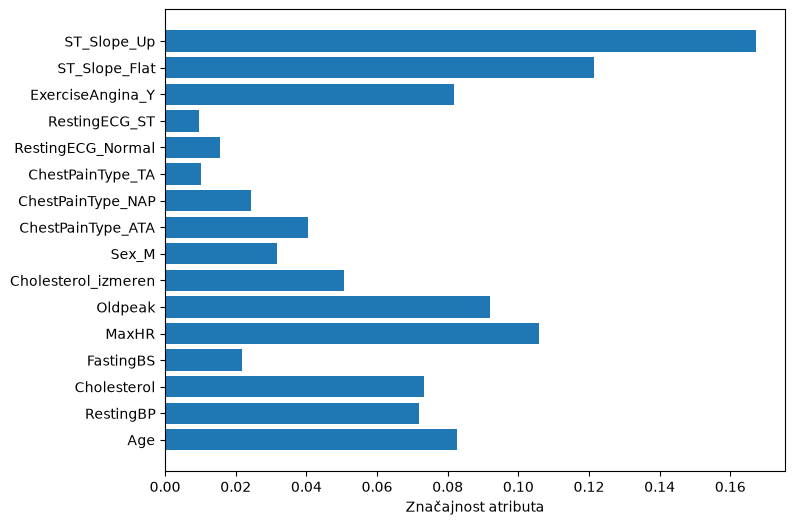

In [82]:
plt.figure(figsize=(8, 6))
plt.barh(feature_names, modeli_sa_regularizacijom['Slučajna šuma'].feature_importances_)
plt.xlabel('Značajnost atributa')
plt.show()

Kod logističke regresije istu ulogu imaju koeficijenti modela:

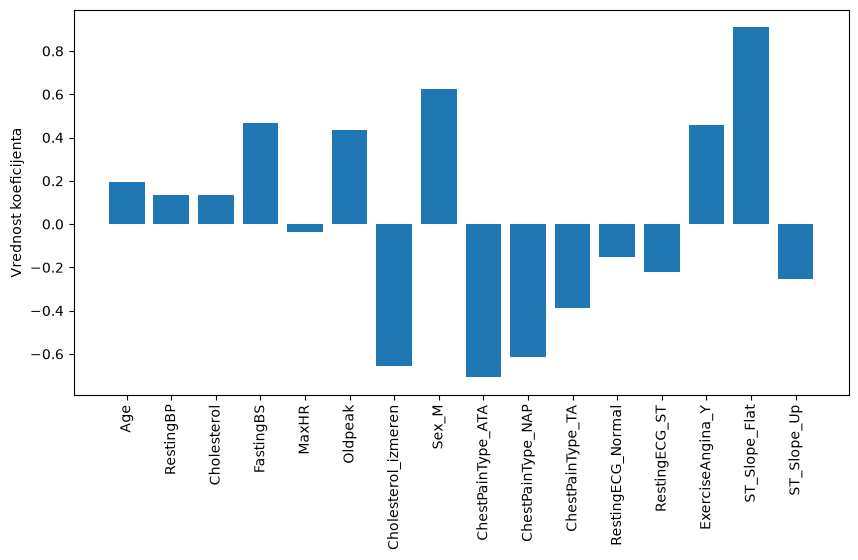

In [83]:
plt.figure(figsize=(10, 5))
plt.bar(feature_names, modeli_sa_regularizacijom['Logistička regresija'].coef_[0])
plt.xticks(rotation='vertical')
plt.ylabel('Vrednost koeficijenta')
plt.show()

Oba modela se najviše oslanjaju na nagib ST segmenta, tip bola u grudima, anginu izazvanu naporom i ST depresiju. To su i atributi koji su imali najjaču korelaciju sa ciljnom promenljivom u prvoj svesci, pa su modeli u tom smislu klinički smisleni.